# TweetBoost — Viral Post Prediction Engine


### Data Loading


In [2]:
import pandas as pd
df=pd.read_csv("Dataset/Tweets/train_tweets.csv")
display(df.head())
display(df.shape)
display(df.info())
display(df["virality"].value_counts())

,tweet_id,tweet_user_id,tweet_created_at_year,tweet_created_at_month,tweet_created_at_day,tweet_created_at_hour,tweet_hashtag_count,tweet_url_count,tweet_mention_count,tweet_has_attachment,tweet_attachment_class,tweet_language_id,tweet_topic_ids,virality
0,34698,10,2015,12,5,3,2.0,1.0,0.0,False,C,0,"['36', '36', '36', '36', '36', '36', '37', '37...",3
1,24644,4,2020,6,19,0,0.0,1.0,0.0,False,C,0,"['43', '78', '79', '80', '80', '89', '98', '99...",3
2,36321,54,2019,6,2,15,2.0,3.0,0.0,True,A,0,"['79', '80', '98', '98', '98', '99', '99', '10...",1
3,2629,42,2020,9,6,17,0.0,1.0,1.0,True,A,0,"['43', '79', '80', '98', '99', '99', '79', '80']",2
4,28169,32,2020,11,4,17,2.0,1.0,0.0,True,A,0,"['79', '80', '98', '99', '43', '89']",2


(29625, 14)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29625 entries, 0 to 29624
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   tweet_id                29625 non-null  int64  
 1   tweet_user_id           29625 non-null  int64  
 2   tweet_created_at_year   29625 non-null  int64  
 3   tweet_created_at_month  29625 non-null  int64  
 4   tweet_created_at_day    29625 non-null  int64  
 5   tweet_created_at_hour   29625 non-null  int64  
 6   tweet_hashtag_count     29625 non-null  float64
 7   tweet_url_count         29625 non-null  float64
 8   tweet_mention_count     29625 non-null  float64
 9   tweet_has_attachment    29625 non-null  bool   
 10  tweet_attachment_class  29625 non-null  object 
 11  tweet_language_id       29625 non-null  int64  
 12  tweet_topic_ids         25340 non-null  object 
 13  virality                29625 non-null  int64  
dtypes: bool(1), float64(3), int64(8), obje

None

virality
1    13632
2     8889
3     4646
5     1323
4     1135
Name: count, dtype: int64

### Data Cleaning

In [34]:
#creating a new field
df["is_viral"]=df["virality"].map({1:0,2:0,3:0,4:1,5:1})
# df=df.drop("tweet_id",axis=1)
df=df.rename(columns={"tweet_attachment_class01":"tweet_attachment_class"})
df["tweet_topic_ids"]=df["tweet_topic_ids"].fillna('[]')
df["topic_count"]=df["tweet_topic_ids"].apply(lambda x: len(set(x)))
# df["tweets_attachment_class"]=df["tweet_attachment_class"].map({'A':'image','B':'video','C':'none'})
# df=df.drop('tweet_attachment_class',axis=1)
# df=df.drop("tweet_topic_ids",axis=1)
df.to_csv("cleaned_tweetboost.csv",index=False) #saving cleaned csv

### EDA

#### Plot 01 - Target Distribution
This dataset is highly imbalanced. Only 8.3% of tweets are viral.

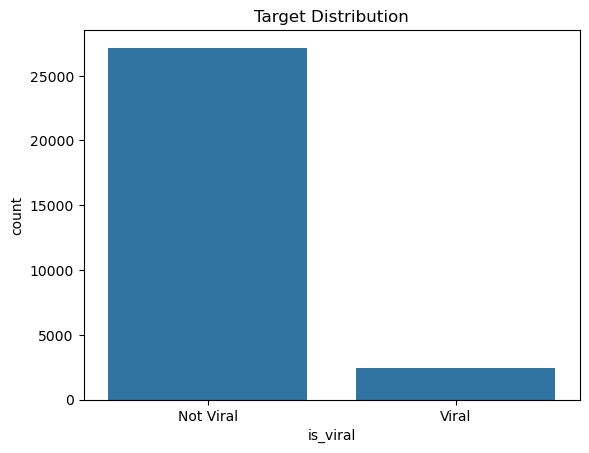

In [35]:
import seaborn as sns
import matplotlib.pyplot as plt 

sns.countplot(x=df["is_viral"],data=df)
plt.xticks([0,1],["Not Viral","Viral"])
plt.title("Target Distribution")
plt.show()

#### Plot 02 - Hours of Day vs Virality
**Observation:** Virality peaks at 4 AM (21.8%) and is lowest at 10 AM (4.6%). Late night and early morning hours show higher virality than normal business hours.

**Business Insight:** Posting during low-competition hours (late night) may increase visibility and virality.

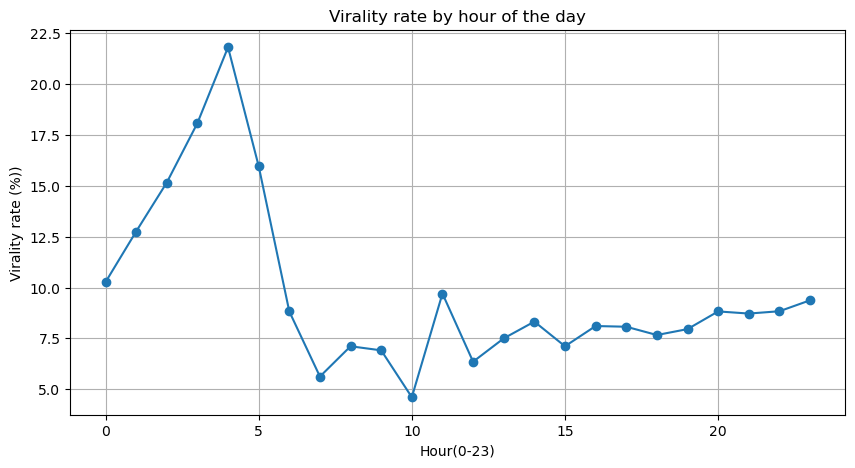

In [36]:
hourly=df.groupby("tweet_created_at_hour")["is_viral"].mean()*100
hourly.plot(kind="line",marker="o",figsize=(10,5))
plt.title("Virality rate by hour of the day")
plt.xlabel("Hour(0-23)")
plt.ylabel("Virality rate (%))")
plt.grid(True)
plt.show()

#### Plot 3- Attachment Type vs Virality
**Observation:** Text-only tweets (none) have the highest virality rate (10.9%), followed by images (6.8%). Videos have the lowest (3.1%).

**Business Insight:** Contrary to common advice, media attachments don't guarantee virality. Well-crafted text content can outperform.

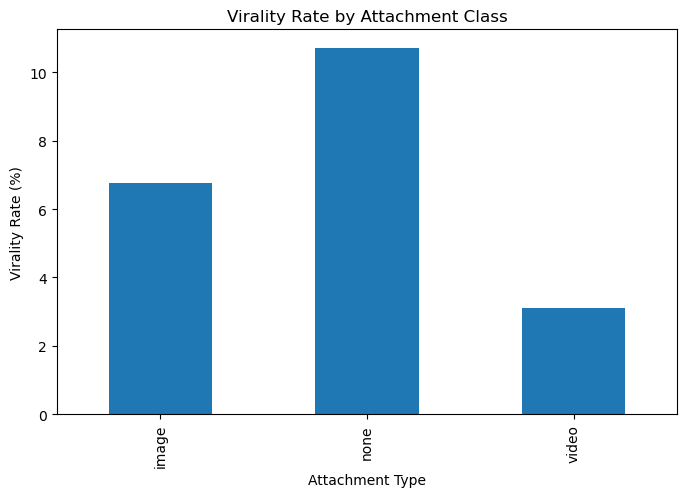

In [37]:
attachement=df.groupby("tweets_attachment_class")["is_viral"].mean()*100
attachement.plot(kind="bar",figsize=(8,5))
plt.title("Virality Rate by Attachment Class")
plt.xlabel("Attachment Type")
plt.ylabel("Virality Rate (%)")
plt.show()

#### Plot 4: Correlation Heatmap
**Observation:** Correlations with `is_viral` are weak (all below ±0.11). This suggests the relationship between features and virality is non-linear. `tweet_hashtag_count` has the strongest (negative) correlation at -0.11.

**Notable Multicollinearity:**
- `tweet_url_count` ↔ `tweet_has_attachment` = 0.64
- `tweet_created_at_year` ↔ `topic_count` = 0.52

**Business Implication:** We need tree-based models (Random Forest, XGBoost) that can capture non-linear patterns. Simple linear models will likely underperform.

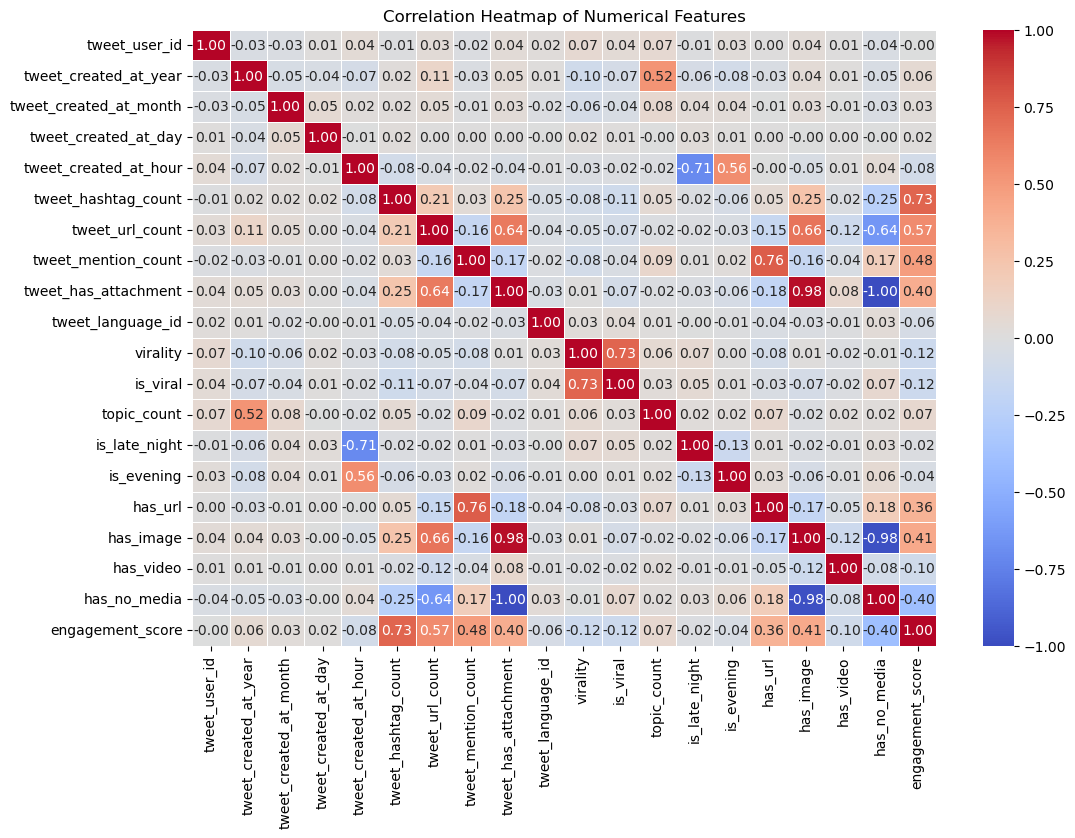

In [38]:
numeric_df=df.select_dtypes(include=["int64",'float64','bool'])
corr_matrix=numeric_df.corr()
plt.figure(figsize=(12,8))
sns.heatmap(corr_matrix,annot=True,cmap="coolwarm",fmt=".2f",linewidths=0.5)
plt.title("Correlation Heatmap of Numerical Features")
plt.show()

### Feature Engineering
Creating news columns

In [41]:
#Feature 01: is_late_night
df["is_late_night"]=df["tweet_created_at_hour"].apply(lambda x: 1 if 0<=x<=5 else 0)

#feature 02: is evening?
df["is_evening"]=df["tweet_created_at_hour"].apply(lambda x: 1 if 20<=x<=23 else 0)

#feature 03: Has URL?
df["has_url"]=df["tweet_url_count"].apply(lambda x: 1 if x>0 else 0)

#feature 04: Has mention?
df["has_url"]=df["tweet_mention_count"].apply(lambda x: 1 if x>0 else 0)

#feature 05: 
df["hashtag_intensity"]=pd.cut(df["tweet_hashtag_count"],bins=[-1,0,2,5,10,100],labels=['none','low','medium','high','extreme'])

#feature 06: Media type files 
df['has_image']=df["tweets_attachment_class"].apply(lambda x: 1 if x=="image" else 0)
df['has_video']=df["tweets_attachment_class"].apply(lambda x: 1 if x=="video" else 0)
df['has_no_media']=df["tweets_attachment_class"].apply(lambda x: 1 if x=="none" else 0)

#feature 07: Engagement score
df["engagement_score"]=df["tweet_hashtag_count"]+df["tweet_mention_count"]+df["tweet_url_count"]

In [47]:
df.to_csv("tweetboost_featured.csv",index=False) #Saving the featured dataset 

In [84]:
#Encoding the categorical fields

from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
df["hashtag_intensity"]=le.fit_transform(df["hashtag_intensity"])
df["tweets_attachment_class"]=le.fit_transform(df["tweets_attachment_class"])
df.groupby('hashtag_intensity')['tweet_hashtag_count'].agg(['min', 'max', 'count'])

,min,max,count
hashtag_intensity,,,
0,11.0,14.0,4
1,6.0,10.0,90
2,1.0,2.0,14994
3,3.0,5.0,3102
4,0.0,0.0,11435


### Model Training 

In [3]:
df=pd.read_csv('tweetboost_featured.csv')
df=df.drop("tweets_attachment_class",axis=1)
df['hashtag_intensity'] = df['hashtag_intensity'].map({
    'extreme': 0,
    'high': 1,
    'low': 2,
    'medium': 3,
    'none': 4
})
from sklearn.ensemble import RandomForestClassifier

from sklearn.model_selection import train_test_split
X=df.drop("is_viral",axis=1)
y=df["is_viral"]
#Data is splitting for training and testing 
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

#model training
model=RandomForestClassifier(n_estimators=100,class_weight="balanced",n_jobs=-1,random_state=42)
model.fit(X_train,y_train)

RandomForestClassifier(class_weight='balanced', n_jobs=-1, random_state=42)

### Model Evaluation

In [4]:
from sklearn.metrics import classification_report
#model prediction against the test data 
y_pred=model.predict(X_test)

print(classification_report(y_test,y_pred,target_names=["Not Viral","Viral"]))

              precision    recall  f1-score   support

   Not Viral       0.94      0.99      0.96      5412
       Viral       0.78      0.32      0.45       513

    accuracy                           0.93      5925
   macro avg       0.86      0.65      0.71      5925
weighted avg       0.92      0.93      0.92      5925



### Hyperparameter tuning

In [5]:
param_grid={
    "n_estimators":[50,100,200],
    "max_depth":[None,5,10],
    "min_samples_split":[2,5],}

from sklearn.model_selection import GridSearchCV
clf=RandomForestClassifier(n_jobs=-1,class_weight='balanced',random_state=42,)
grid=GridSearchCV(clf,param_grid,cv=3,scoring='f1',n_jobs=-1,verbose=1)
grid.fit(X_train,y_train)

Fitting 3 folds for each of 18 candidates, totalling 54 fits


GridSearchCV(cv=3,
             estimator=RandomForestClassifier(class_weight='balanced',
                                              n_jobs=-1, random_state=42),
             n_jobs=-1,
             param_grid={'max_depth': [None, 5, 10],
                         'min_samples_split': [2, 5],
                         'n_estimators': [50, 100, 200]},
             scoring='f1', verbose=1)

In [6]:
best_clf = grid.best_estimator_
y_pred_best = best_clf.predict(X_test)

print("Best params:", grid.best_params_)
print("Best CV F1:", grid.best_score_)
print(classification_report(y_test, y_pred_best, target_names=["Not Viral", "Viral"]))


Best params: {'max_depth': None, 'min_samples_split': 5, 'n_estimators': 200}
Best CV F1: 0.44591740553907994
              precision    recall  f1-score   support

   Not Viral       0.94      0.98      0.96      5412
       Viral       0.69      0.39      0.50       513

    accuracy                           0.93      5925
   macro avg       0.82      0.68      0.73      5925
weighted avg       0.92      0.93      0.92      5925



### Model Saving 

In [8]:
import joblib
joblib.dump(best_clf,"tweetboost_model.joblib")
#training fields
joblib.dump(list(X_train.columns),"model_columns.joblib")

['model_columns.joblib']

In [9]:
import joblib
import gzip

# Save with compression
with gzip.open('tweetboost_model.joblib.gz', 'wb') as f:
    joblib.dump(best_clf, f)

# Size check
import os
print(f"Size: {os.path.getsize('tweetboost_model.joblib.gz') / 1024 / 1024:.2f} MB")

Size: 13.72 MB
